# IEMOCAP Gender and Emotion Analysis
This notebook loads the target fold metadata from `IEMOCAP_features/IEMOCAP_features_2021/target`, computes gender/emotion distributions for Train, Test, and Validation splits, and visualizes the results.

## Section: Import Libraries


In [10]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid", palette="tab10", font_scale=1.1)
%matplotlib inline

## Section: Load Dataset


In [11]:
# Load folder metadata and build a combined dataset

base_dir = r"IEMOCAP_features/IEMOCAP_features_2021/target"
if not os.path.isdir(base_dir):
    base_dir = os.path.abspath(base_dir)

EMOTION_ORDER = ["angry", "happy", "neutral", "sad"]
SPLIT_LABELS = {"trn": "Train", "tst": "Test", "val": "Validation"}
SPLIT_ORDER = ["Train", "Test", "Validation"]
GENDER_PATTERN = re.compile(r"Ses\d+(F|M)")


def decode_name(name):
    if isinstance(name, (bytes, np.bytes_)):
        return name.decode("utf-8", errors="replace")
    if isinstance(name, np.ndarray):
        if name.dtype.kind in ("S", "U"):
            value = name.item()
            if isinstance(value, (bytes, np.bytes_)):
                return value.decode("utf-8", errors="replace")
            return str(value)
        if name.size == 1:
            return str(name.item())
        return [decode_name(item) for item in name]
    return str(name)


def parse_gender(name):
    name = decode_name(name)
    match = GENDER_PATTERN.search(name)
    if match:
        return "female" if match.group(1) == "F" else "male"
    if "_F" in name or "F_" in name:
        return "female"
    if "_M" in name or "M_" in name:
        return "male"
    return "unknown"


def load_fold_split(fold_dir, split_name):
    names_path = os.path.join(fold_dir, f"{split_name}_int2name.npy")
    labels_path = os.path.join(fold_dir, f"{split_name}_label.npy")
    names = np.load(names_path, allow_pickle=True)
    labels = np.load(labels_path, allow_pickle=True)
    return names, labels


records = []
for fold in sorted([name for name in os.listdir(base_dir) if name.isdigit()], key=int):
    fold_dir = os.path.join(base_dir, fold)
    for split_name in ["trn", "tst", "val"]:
        names, labels = load_fold_split(fold_dir, split_name)
        for name, onehot in zip(names, labels):
            gender = parse_gender(name)
            emotion_idx = int(np.argmax(onehot))
            emotion = EMOTION_ORDER[emotion_idx]
            records.append({
                "fold": int(fold),
                "split": SPLIT_LABELS[split_name],
                "name": decode_name(name),
                "gender": gender,
                "emotion": emotion,
            })

all_df = pd.DataFrame(records)
all_df.head()

,fold,split,name,gender,emotion
0,1,Train,Ses02F_script03_1_M001,female,neutral
1,1,Train,Ses02F_script03_1_M004,female,neutral
2,1,Train,Ses02F_script03_1_M005,female,neutral
3,1,Train,Ses02F_script03_1_M007,female,neutral
4,1,Train,Ses02F_script03_1_M008,female,neutral


## Section: Inspect and Clean Data


In [12]:
# Inspect and clean the loaded data

print(f"Loaded {len(all_df)} examples")
print(all_df["split"].value_counts())
print(all_df["gender"].value_counts())
print(all_df["emotion"].value_counts())

all_df.sample(10, random_state=42)

Loaded 55310 examples
split
Train         44248
Test           5556
Validation     5506
Name: count, dtype: int64
gender
male      27860
female    27450
Name: count, dtype: int64
emotion
neutral    17080
happy      16360
angry      11030
sad        10840
Name: count, dtype: int64


,fold,split,name,gender,emotion
36675,7,Train,Ses05F_script03_1_M021,female,happy
4251,1,Train,Ses05M_script02_2_F010,male,angry
26053,5,Train,Ses05M_impro07_F009,male,happy
31439,6,Train,Ses05F_impro04_M038,female,neutral
19387,4,Train,Ses04M_impro07_F004,male,happy
7640,2,Train,Ses03M_impro05b_F019,male,neutral
2191,1,Train,Ses04F_script01_2_M007,female,neutral
25141,5,Train,Ses04F_impro07_F035,female,happy
42548,8,Train,Ses05F_impro05_M048,female,neutral
28748,6,Train,Ses02F_script03_1_M013,female,neutral


## Section: Create Basic Charts


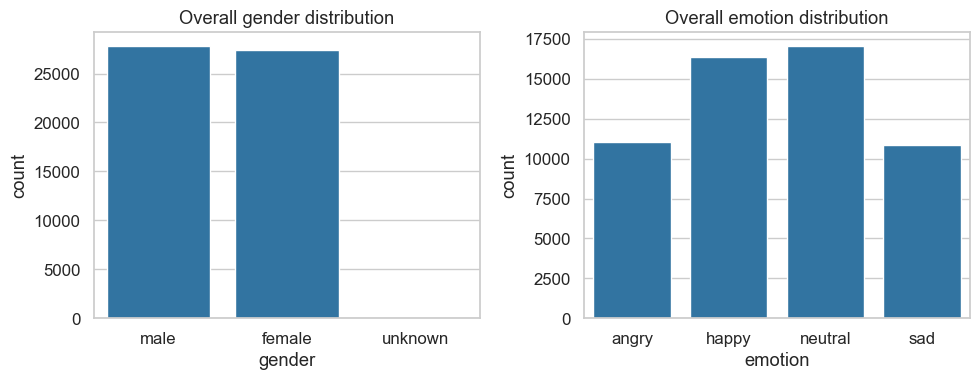

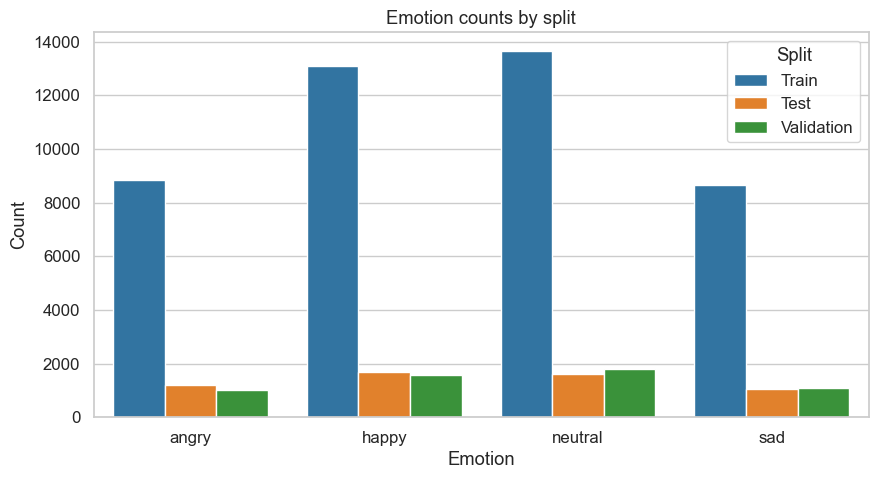

In [13]:
# Create basic charts

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.countplot(data=all_df, x="gender", order=["male", "female", "unknown"])
plt.title("Overall gender distribution")

plt.subplot(1, 2, 2)
sns.countplot(data=all_df, x="emotion", order=EMOTION_ORDER)
plt.title("Overall emotion distribution")
plt.tight_layout()

# Split-level emotion counts
plt.figure(figsize=(10, 5))
sns.countplot(data=all_df, x="emotion", hue="split", order=EMOTION_ORDER, hue_order=SPLIT_ORDER)
plt.title("Emotion counts by split")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.legend(title="Split")
plt.show()

## Section: Visualize Relationships


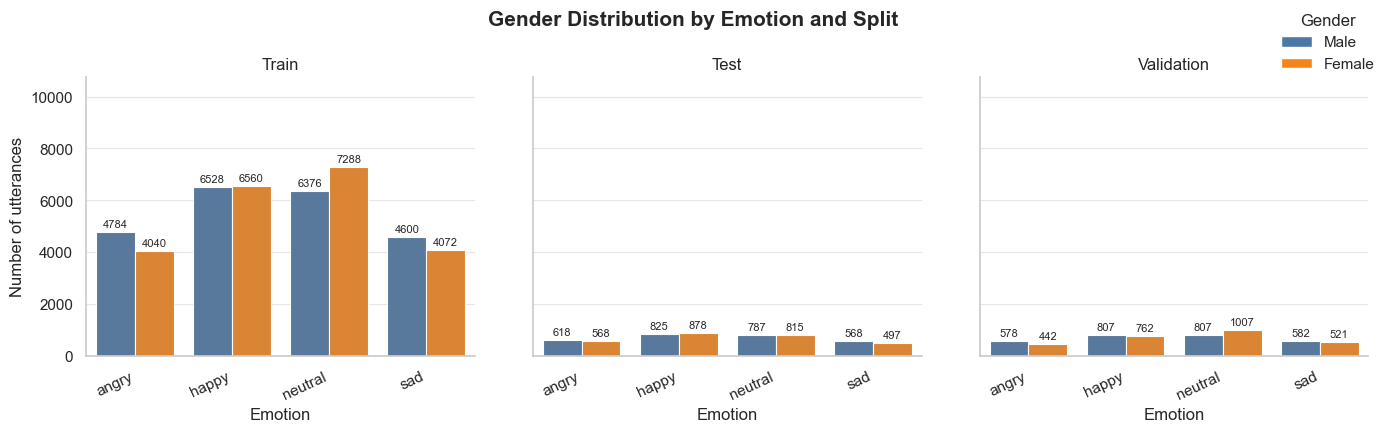

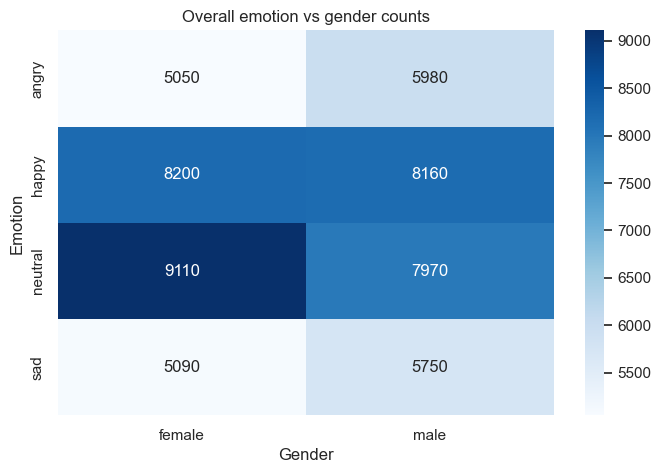

In [14]:
# Visualize relationships between gender, emotion, and split

sns.set_theme(style="whitegrid", context="notebook")

gender_palette = {
    "male": "#4C78A8",
    "female": "#F58518",

}

g = sns.catplot(
    data=all_df,
    kind="count",
    x="emotion",
    hue="gender",
    col="split",
    order=EMOTION_ORDER,
    col_order=SPLIT_ORDER,
    hue_order=["male", "female"],
    palette=gender_palette,
    height=4.2,
    aspect=1.1,
    edgecolor="white",
    linewidth=0.8,
    legend=False,
)

g.set_axis_labels("Emotion", "Number of utterances")
g.set_titles("{col_name}")
g.set_xticklabels(rotation=25, ha="right")

for ax in g.axes.flat:
    for container in ax.containers:
        ax.bar_label(container, padding=2, fontsize=8)
    ax.grid(axis="y", color="#E6E6E6", linewidth=0.8)
    ax.grid(axis="x", visible=False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.12)

# Create an explicit, figure-level legend using colored patches so it appears in saved PNGs
from matplotlib.patches import Patch
legend_order = ["male", "female"]
legend_handles = [Patch(facecolor=gender_palette.get(k, "#777777"), edgecolor="white") for k in legend_order]
legend_labels = [k.capitalize() for k in legend_order]
g.fig.legend(handles=legend_handles, labels=legend_labels, title="Gender", loc="upper right", frameon=False)
g.fig.subplots_adjust(top=0.82, wspace=0.15)
g.fig.suptitle("Gender Distribution by Emotion and Split", fontsize=15, fontweight="bold")
plt.show()

# Heatmap of counts per emotion and gender for the entire dataset
pivot = all_df.groupby(["emotion", "gender"]).size().unstack(fill_value=0).reindex(EMOTION_ORDER)
plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt="d", cmap="Blues")
plt.title("Overall emotion vs gender counts")
plt.ylabel("Emotion")
plt.xlabel("Gender")
plt.show()

## Section: Display Summary Statistics


In [15]:
# Display summary statistics and key findings

summary_table = all_df.groupby(["split", "emotion", "gender"]).size().reset_index(name="count")
summary_table["percent_of_emotion"] = summary_table.groupby(["split", "emotion"])["count"].transform(lambda x: x / x.sum() * 100)
summary_table.head(12)

# Show overall percentages for each emotion and gender.
percent_table = all_df.groupby(["emotion", "gender"]).size().reset_index(name="count")
percent_table["pct"] = percent_table.groupby("emotion")["count"].transform(lambda x: x / x.sum() * 100)
percent_table = percent_table.drop(columns=["count"])
percent_table

,emotion,gender,pct
0,angry,female,45.784225
1,angry,male,54.215775
2,happy,female,50.122249
3,happy,male,49.877751
4,neutral,female,53.337237
5,neutral,male,46.662763
6,sad,female,46.955720
7,sad,male,53.044280
